In [1]:
import sys

print (sys.executable)

/Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/.venv/bin/python


# Optimisation et interprétation du modèle

## Contexte et objectif

Cette
étape
vise
à
optimiser
le
modèle
non
linéaire
retenu
à
l’étape
précédente, puis
à
interpréter
son
comportement
à
l’aide
de
méthodes
d’explicabilité
globale
et
locale.

Les
objectifs
sont
les
suivants:
- améliorer
les
performances
du
modèle
par
fine - tuning;
- comparer
plusieurs
méthodes
de
feature
importance
globale;
- analyser
l’effet
des
variables
sur
les
prédictions
individuelles.

Le
modèle
retenu
ici
est
une ** Random
Forest **, adaptée
à
un
problème
non
linéaire
et
compatible
avec ** TreeExplainer ** de
SHAP.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
)
from sklearn.preprocessing import OneHotEncoder

sns.set_theme (style="whitegrid")
pd.set_option ("display.max_columns", 200)

## 1. Chargement des données préparées

Les données nettoyées et consolidées à l’étape précédente sont rechargées à partir du dossier `data/processed`.

La variable cible est ensuite standardisée puis encodée sous forme binaire afin de faciliter l’entraînement et l’évaluation du modèle.

In [3]:
PROJECT_ROOT = Path.cwd ( ).resolve ( ).parent if Path.cwd ( ).name == "notebooks" else Path.cwd ( ).resolve ( )
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

df_central = pd.read_csv (DATA_PROCESSED / "df_central.csv")

df_central["a_quitte_l_entreprise"] = (
    df_central["a_quitte_l_entreprise"]
    .astype (str)
    .str.strip ( )
    .str.capitalize ( )
)

df_central["attrition_bin"] = df_central["a_quitte_l_entreprise"].apply (
    lambda x: 1 if x == "Oui" else 0
)

print ("PROJECT_ROOT :", PROJECT_ROOT)
print ("DATA_PROCESSED :", DATA_PROCESSED)
print ("df_central shape :", df_central.shape)
display (df_central.head ( ))

PROJECT_ROOT : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations 13.39.35
DATA_PROCESSED : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations 13.39.35/data/processed
df_central shape : (1470, 35)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,attrition_bin
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,E_1,3,Oui,11 %,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5,1
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,E_2,4,Non,23 %,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7,0
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,E_4,3,Oui,15 %,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0,1
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,E_5,3,Oui,11 %,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,E_7,3,Non,12 %,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2,0


## 2. Fonctions utilitaires de préparation

Les fonctions ci-dessous permettent de structurer la préparation des données de manière plus lisible et réutilisable.

Elles prennent en charge :
- l’identification des variables numériques et catégorielles ;
- la construction de la cible ;
- la création de la matrice de features ;
- l’encodage des variables catégorielles ;
- la suppression des variables trop fortement corrélées.

In [4]:
def split_features_by_type(df: pd.DataFrame):
    num_cols = df.select_dtypes (include=["number"]).columns.tolist ( )
    cat_cols = df.select_dtypes (include=["object", "string", "category"]).columns.tolist ( )
    return num_cols, cat_cols


def build_target(df: pd.DataFrame, target_col: str = "attrition_bin") -> pd.Series:
    return df[target_col].copy ( )


def build_feature_matrix(
        df: pd.DataFrame,
        cols_to_drop: list[str] | None = None
) -> pd.DataFrame:
    if cols_to_drop is None:
        cols_to_drop = [
            "a_quitte_l_entreprise",
            "attrition_bin",
            "id_employee",
            "code_sondage",
            "eval_number",
        ]
    return df.drop (columns=[col for col in cols_to_drop if col in df.columns]).copy ( )


def fit_encoder_on_train(df: pd.DataFrame):
    df = df.copy ( )
    num_cols, cat_cols = split_features_by_type (df)

    if not cat_cols:
        return None, df

    encoder = OneHotEncoder (
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    encoded_array = encoder.fit_transform (df[cat_cols])

    encoded_df = pd.DataFrame (
        encoded_array,
        columns=encoder.get_feature_names_out (cat_cols),
        index=df.index
    )

    df_encoded = pd.concat ([df[num_cols], encoded_df], axis=1)
    return encoder, df_encoded


def transform_with_encoder(df: pd.DataFrame, encoder) -> pd.DataFrame:
    df = df.copy ( )
    num_cols, cat_cols = split_features_by_type (df)

    if encoder is None or not cat_cols:
        return df

    encoded_array = encoder.transform (df[cat_cols])

    encoded_df = pd.DataFrame (
        encoded_array,
        columns=encoder.get_feature_names_out (cat_cols),
        index=df.index
    )

    return pd.concat ([df[num_cols], encoded_df], axis=1)


def drop_highly_correlated_features(df: pd.DataFrame, threshold: float = 0.8):
    corr_matrix = df.corr (numeric_only=True).abs ( )
    upper = corr_matrix.where (np.triu (np.ones (corr_matrix.shape), k=1).astype (bool))
    to_drop = [column for column in upper.columns if any (upper[column] > threshold)]
    return df.drop (columns=to_drop), to_drop

## 3. Feature engineering

Quelques
variables
dérivées
sont
construites
afin
d’enrichir
la
représentation
initiale
des
employés.

L’objectif
est
de
faire
émerger
des
signaux
potentiellement
utiles
à
la
classification, par
exemple
en
combinant:
- le
revenu
et
l’expérience;
- l’ancienneté
relative;
- la
charge
liée
à
la
distance
domicile - travail;
- un
score
synthétique
de
satisfaction.

In [5]:
df_fe = df_central.copy ( )

df_fe["revenu_par_annee_experience"] = (
        df_fe["revenu_mensuel"] / (df_fe["annee_experience_totale"] + 1)
)

df_fe["part_anciennete_entreprise"] = (
        df_fe["annees_dans_l_entreprise"] / (df_fe["annee_experience_totale"] + 1)
)

df_fe["part_anciennete_poste"] = (
        df_fe["annees_dans_le_poste_actuel"] / (df_fe["annees_dans_l_entreprise"] + 1)
)

df_fe["charge_distance"] = (
        df_fe["distance_domicile_travail"] * df_fe["nombre_heures_travailless"]
)

satisfaction_cols = [
    "satisfaction_employee_environnement",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
]

existing_satisfaction_cols = [col for col in satisfaction_cols if col in df_fe.columns]

if existing_satisfaction_cols:
    df_fe["score_satisfaction_moyen"] = df_fe[existing_satisfaction_cols].mean (axis=1)

print ("df_fe shape :", df_fe.shape)
display (df_fe.head ( ))

df_fe shape : (1470, 40)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,attrition_bin,revenu_par_annee_experience,part_anciennete_entreprise,part_anciennete_poste,charge_distance,score_satisfaction_moyen
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,E_1,3,Oui,11 %,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5,1,665.888889,0.666667,0.571429,80,2.00
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,E_2,4,Non,23 %,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7,0,466.363636,0.909091,0.636364,640,3.00
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,E_4,3,Oui,15 %,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0,1,261.250000,0.000000,0.000000,160,3.00
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,E_5,3,Oui,11 %,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0,0,323.222222,0.888889,0.777778,240,3.25
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,E_7,3,Non,12 %,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2,0,495.428571,0.285714,0.666667,160,2.50


## 4. Construction de la cible et des features

La
variable
cible
`attrition_bin`
est
isolée, puis
les
variables
explicatives
sont
regroupées
dans
une
matrice
de
features.

In [6]:
y = build_target (df_fe)
X_raw = build_feature_matrix (df_fe)

print ("X_raw shape :", X_raw.shape)
print ("y shape :", y.shape)

X_raw shape : (1470, 35)
y shape : (1470,)


## 5. Séparation train / test

Le jeu de test est conservé à part pour l’évaluation finale.

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split (
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print ("X_train_raw :", X_train_raw.shape)
print ("X_test_raw  :", X_test_raw.shape)
print ("y_train     :", y_train.shape)
print ("y_test      :", y_test.shape)

print ("\nRépartition y_train :")
print (y_train.value_counts (normalize=True))

print ("\nRépartition y_test :")
print (y_test.value_counts (normalize=True))

X_train_raw : (1176, 35)
X_test_raw  : (294, 35)
y_train     : (1176,)
y_test      : (294,)

Répartition y_train :
attrition_bin
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Répartition y_test :
attrition_bin
0    0.840136
1    0.159864
Name: proportion, dtype: float64


## 6. Encodage des variables et préparation finale

Les
variables
catégorielles
sont
encodées
à
partir
du
seul
jeu
d’apprentissage
afin
d’éviter
toute
fuite
d’information.

Les
variables
trop
corrélées
sont
ensuite
retirées, puis
les
jeux
train
et
test
sont
réalignés
pour
garantir
la
même
structure
finale.

In [8]:
encoder, X_train_prepared = fit_encoder_on_train (X_train_raw)
X_test_prepared = transform_with_encoder (X_test_raw, encoder)

X_train, dropped_corr_features = drop_highly_correlated_features (
    X_train_prepared,
    threshold=0.8
)

X_test = X_test_prepared.drop (columns=dropped_corr_features, errors="ignore")

X_train, X_test = X_train.align (
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print ("Shape final de X_train :", X_train.shape)
print ("Shape final de X_test  :", X_test.shape)
print ("NaN dans X_train :", X_train.isna ( ).sum ( ).sum ( ))
print ("NaN dans X_test  :", X_test.isna ( ).sum ( ).sum ( ))
print ("Nombre de variables supprimées :", len (dropped_corr_features))

Shape final de X_train : (1176, 58)
Shape final de X_test  : (294, 58)
NaN dans X_train : 0
NaN dans X_test  : 0
Nombre de variables supprimées : 3


## 7. Création d’un sous-jeu de validation

Le
jeu
de
test
reste
totalement
à
l’écart.

Le
jeu
d’apprentissage
est
séparé
en:
- un
sous - jeu
d’entraînement
pour
le
fine - tuning;
- un
sous - jeu
de
validation
pour
choisir
le
seuil
de
décision.

In [9]:
X_subtrain, X_valid, y_subtrain, y_valid = train_test_split (
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

print ("X_subtrain :", X_subtrain.shape)
print ("X_valid    :", X_valid.shape)
print ("X_test     :", X_test.shape)

print ("\nRépartition y_subtrain :")
print (y_subtrain.value_counts (normalize=True))

print ("\nRépartition y_valid :")
print (y_valid.value_counts (normalize=True))

print ("\nRépartition y_test :")
print (y_test.value_counts (normalize=True))

X_subtrain : (940, 58)
X_valid    : (236, 58)
X_test     : (294, 58)

Répartition y_subtrain :
attrition_bin
0    0.838298
1    0.161702
Name: proportion, dtype: float64

Répartition y_valid :
attrition_bin
0    0.838983
1    0.161017
Name: proportion, dtype: float64

Répartition y_test :
attrition_bin
0    0.840136
1    0.159864
Name: proportion, dtype: float64


## 8. Fine-tuning de la Random Forest

La
recherche
d’hyperparamètres
est
réalisée
par
validation
croisée
stratifiée
sur
le
sous - jeu
d’entraînement.

Le
score
retenu
est ** average
precision **, plus
pertinent
qu’une
simple
accuracy
dans
un
contexte
déséquilibré.

In [10]:
rf_base = RandomForestClassifier (
    random_state=42,
    n_jobs=-1,
)

param_distributions = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [None, 6, 8, 10, 12, 16, 20],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "class_weight": ["balanced", "balanced_subsample"],
    "bootstrap": [True],
}

cv = StratifiedKFold (
    n_splits=5,
    shuffle=True,
    random_state=42,
)

random_search = RandomizedSearchCV (
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    refit=True,
)

random_search.fit (X_subtrain, y_subtrain)

print ("Meilleurs paramètres :")
print (random_search.best_params_)

print ("\nMeilleur score CV (average precision) :")
print (round (random_search.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs paramètres :
{'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 12, 'class_weight': 'balanced', 'bootstrap': True}

Meilleur score CV (average precision) :
0.5604


## 6. Feature importance globale — Permutation Importance

La permutation importance mesure la baisse de performance provoquée par la perturbation d’une variable.

Elle est souvent plus fidèle au comportement réel du modèle que l’importance native.

In [11]:
best_rf_final = RandomForestClassifier (
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1,
)

best_rf_final.fit (X_train, y_train)

print (best_rf_final)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=4, min_samples_split=5,
                       n_estimators=800, n_jobs=-1, random_state=42)


In [12]:
perm = permutation_importance (
    best_rf_final,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
    scoring="average_precision",
)

permutation_imp = (
    pd.Series (perm.importances_mean, index=X_test.columns)
    .sort_values (ascending=False)
)

display (permutation_imp.head (20))

heure_supplementaires_Oui                0.091359
nombre_participation_pee                 0.024449
score_satisfaction_moyen                 0.007635
satisfaction_employee_nature_travail     0.007189
frequence_deplacement_Frequent           0.005789
note_evaluation_precedente               0.004342
distance_domicile_travail                0.004046
statut_marital_Marié(e)                  0.003237
nb_formations_suivies                    0.002956
satisfaction_employee_environnement      0.002679
annees_depuis_la_derniere_promotion      0.002223
revenu_mensuel                           0.001822
note_evaluation_actuelle                 0.001625
statut_marital_Divorcé(e)                0.001605
poste_Cadre Commercial                   0.001551
domaine_etude_Entrepreunariat            0.001441
domaine_etude_Transformation Digitale    0.001426
poste_Manager                            0.001403
frequence_deplacement_Occasionnel        0.001051
departement_Consulting                   0.000813


In [13]:
cv_results = pd.DataFrame (random_search.cv_results_).sort_values ("rank_test_score")

display (
    cv_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "param_n_estimators",
            "param_max_depth",
            "param_min_samples_split",
            "param_min_samples_leaf",
            "param_max_features",
            "param_class_weight",
        ]
    ].head (10)
)

,rank_test_score,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,param_class_weight
22,1,0.560439,0.051844,800,12,5,4,sqrt,balanced
26,2,0.558545,0.048493,1000,None,10,4,log2,balanced
7,3,0.558534,0.053171,400,None,2,4,sqrt,balanced_subsample
12,4,0.556156,0.047142,1000,12,20,4,sqrt,balanced_subsample
27,5,0.555923,0.048222,1000,12,5,8,log2,balanced
18,6,0.555613,0.055073,200,None,5,4,log2,balanced_subsample
9,7,0.555188,0.049747,600,20,20,4,log2,balanced_subsample
20,8,0.555163,0.053422,400,10,20,1,log2,balanced_subsample
24,9,0.554675,0.050838,600,10,20,2,log2,balanced
4,10,0.554358,0.047844,1000,8,5,8,sqrt,balanced_subsample


## 9. Choix du seuil de décision sur validation

Le meilleur modèle issu du fine-tuning est entraîné sur le sous-jeu d’entraînement.

Le seuil de décision est ensuite choisi sur le jeu de validation à partir de la courbe précision-rappel, sans utiliser le jeu de test.

In [14]:
best_rf = random_search.best_estimator_
best_rf.fit (X_subtrain, y_subtrain)

y_valid_scores = best_rf.predict_proba (X_valid)[:, 1]

precision_valid, recall_valid, thresholds_valid = precision_recall_curve (y_valid, y_valid_scores)

if len (thresholds_valid) > 0:
    f1_scores_valid = (
            2 * precision_valid[:-1] * recall_valid[:-1]
            / (precision_valid[:-1] + recall_valid[:-1] + 1e-9)
    )
    best_idx = np.nanargmax (f1_scores_valid)
    best_threshold = float (thresholds_valid[best_idx])
else:
    best_threshold = 0.5
    f1_scores_valid = np.array ([])

print ("Seuil optimal choisi sur validation :", round (best_threshold, 3))

Seuil optimal choisi sur validation : 0.467


In [15]:
threshold_df = pd.DataFrame ({
    "threshold": thresholds_valid,
    "precision": precision_valid[:-1],
    "recall": recall_valid[:-1],
    "f1": f1_scores_valid,
})

display (threshold_df.sort_values ("f1", ascending=False).head (10))

,threshold,precision,recall,f1
204,0.466563,0.562500,0.473684,0.514286
200,0.431428,0.527778,0.500000,0.513514
203,0.454531,0.545455,0.473684,0.507042
199,0.425955,0.513514,0.500000,0.506667
206,0.493486,0.566667,0.447368,0.500000
202,0.453129,0.529412,0.473684,0.500000
198,0.418976,0.500000,0.500000,0.500000
185,0.340126,0.431373,0.578947,0.494382
189,0.362210,0.446809,0.552632,0.494118
197,0.405040,0.487179,0.500000,0.493506


## 10. Réentraînement final et évaluation sur test

Le
modèle
final
est
réentraîné
sur
l’ensemble
du
jeu
d’apprentissage
avec
les
meilleurs
hyperparamètres.

Le
seuil
retenu
sur
validation
est
ensuite
appliqué
au
jeu
de
test.

In [16]:
best_rf_final = RandomForestClassifier (
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1,
)

best_rf_final.fit (X_train, y_train)

y_train_scores = best_rf_final.predict_proba (X_train)[:, 1]
y_test_scores = best_rf_final.predict_proba (X_test)[:, 1]

y_train_pred_default = (y_train_scores >= 0.5).astype (int)
y_test_pred_default = (y_test_scores >= 0.5).astype (int)

y_train_pred_threshold = (y_train_scores >= best_threshold).astype (int)
y_test_pred_threshold = (y_test_scores >= best_threshold).astype (int)

results_final = pd.DataFrame([
    {
        "configuration": "train_seuil_0.5",
        "accuracy": accuracy_score(y_train, y_train_pred_default),
        "precision": precision_score(y_train, y_train_pred_default, zero_division=0),
        "recall": recall_score(y_train, y_train_pred_default, zero_division=0),
        "f1": f1_score(y_train, y_train_pred_default, zero_division=0),
        "average_precision": average_precision_score(y_train, y_train_scores),
    },
    {
        "configuration": "test_seuil_0.5",
        "accuracy": accuracy_score(y_test, y_test_pred_default),
        "precision": precision_score(y_test, y_test_pred_default, zero_division=0),
        "recall": recall_score(y_test, y_test_pred_default, zero_division=0),
        "f1": f1_score(y_test, y_test_pred_default, zero_division=0),
        "average_precision": average_precision_score(y_test, y_test_scores),
    },
    {
        "configuration": f"train_seuil_{best_threshold:.3f}",
        "accuracy": accuracy_score(y_train, y_train_pred_threshold),
        "precision": precision_score(y_train, y_train_pred_threshold, zero_division=0),
        "recall": recall_score(y_train, y_train_pred_threshold, zero_division=0),
        "f1": f1_score(y_train, y_train_pred_threshold, zero_division=0),
        "average_precision": average_precision_score(y_train, y_train_scores),
    },
    {
        "configuration": f"test_seuil_{best_threshold:.3f}",
        "accuracy": accuracy_score(y_test, y_test_pred_threshold),
        "precision": precision_score(y_test, y_test_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_test_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_test_pred_threshold, zero_division=0),
        "average_precision": average_precision_score(y_test, y_test_scores),
    },
]).round(3)

display(results_final)

In [17]:
print ("TEST - seuil 0.5")
print (classification_report (y_test, y_test_pred_default, zero_division=0))

print ("\nTEST - seuil optimisé")
print (classification_report (y_test, y_test_pred_threshold, zero_division=0))

TEST - seuil 0.5
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       247
           1       0.45      0.28      0.34        47

    accuracy                           0.83       294
   macro avg       0.66      0.61      0.62       294
weighted avg       0.80      0.83      0.81       294


TEST - seuil optimisé
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       247
           1       0.46      0.36      0.40        47

    accuracy                           0.83       294
   macro avg       0.67      0.64      0.65       294
weighted avg       0.82      0.83      0.82       294



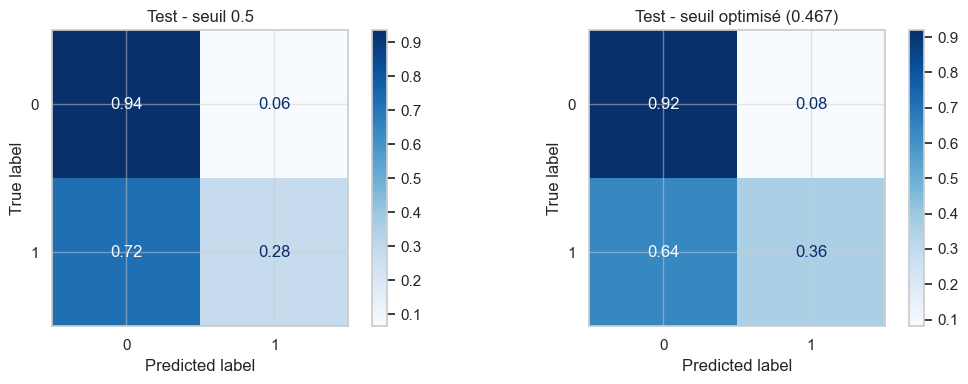

In [18]:
fig, axes = plt.subplots (1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions (
    y_test,
    y_test_pred_default,
    ax=axes[0],
    cmap="Blues",
    normalize="true",
    values_format=".2f",
)
axes[0].set_title ("Test - seuil 0.5")

ConfusionMatrixDisplay.from_predictions (
    y_test,
    y_test_pred_threshold,
    ax=axes[1],
    cmap="Blues",
    normalize="true",
    values_format=".2f",
)
axes[1].set_title (f"Test - seuil optimisé ({best_threshold:.3f})")

plt.tight_layout ( )
plt.show ( )

## 11. Feature importance globale — importance native de la Random Forest

Cette première mesure donne une importance moyenne issue directement du modèle.

Elle est rapide à calculer, mais peut être biaisée en présence de variables corrélées ou de variables à forte cardinalité.

In [19]:
native_importance = (
    pd.Series (best_rf_final.feature_importances_, index=X_train.columns)
    .sort_values (ascending=False)
)

display (native_importance.head (20))

revenu_mensuel                          0.080053
age                                     0.070777
annee_experience_totale                 0.058655
heure_supplementaires_Oui               0.053035
score_satisfaction_moyen                0.052347
revenu_par_annee_experience             0.050708
annees_dans_l_entreprise                0.049794
part_anciennete_entreprise              0.048718
distance_domicile_travail               0.042373
nombre_participation_pee                0.041236
annes_sous_responsable_actuel           0.040081
part_anciennete_poste                   0.038402
nombre_experiences_precedentes          0.036346
annees_dans_le_poste_actuel             0.029074
satisfaction_employee_environnement     0.025553
satisfaction_employee_nature_travail    0.023059
annees_depuis_la_derniere_promotion     0.022253
satisfaction_employee_equipe            0.019962
note_evaluation_precedente              0.017633
niveau_education                        0.017497
dtype: float64

plt.figure(figsize=(8, 6))
native_importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 - importance native de la Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
native_importance = (
    pd.Series (best_rf_final.feature_importances_, index=X_train.columns)
    .sort_values (ascending=False)
)

display (native_importance.head (20))

revenu_mensuel                          0.080053
age                                     0.070777
annee_experience_totale                 0.058655
heure_supplementaires_Oui               0.053035
score_satisfaction_moyen                0.052347
revenu_par_annee_experience             0.050708
annees_dans_l_entreprise                0.049794
part_anciennete_entreprise              0.048718
distance_domicile_travail               0.042373
nombre_participation_pee                0.041236
annes_sous_responsable_actuel           0.040081
part_anciennete_poste                   0.038402
nombre_experiences_precedentes          0.036346
annees_dans_le_poste_actuel             0.029074
satisfaction_employee_environnement     0.025553
satisfaction_employee_nature_travail    0.023059
annees_depuis_la_derniere_promotion     0.022253
satisfaction_employee_equipe            0.019962
note_evaluation_precedente              0.017633
niveau_education                        0.017497
dtype: float64

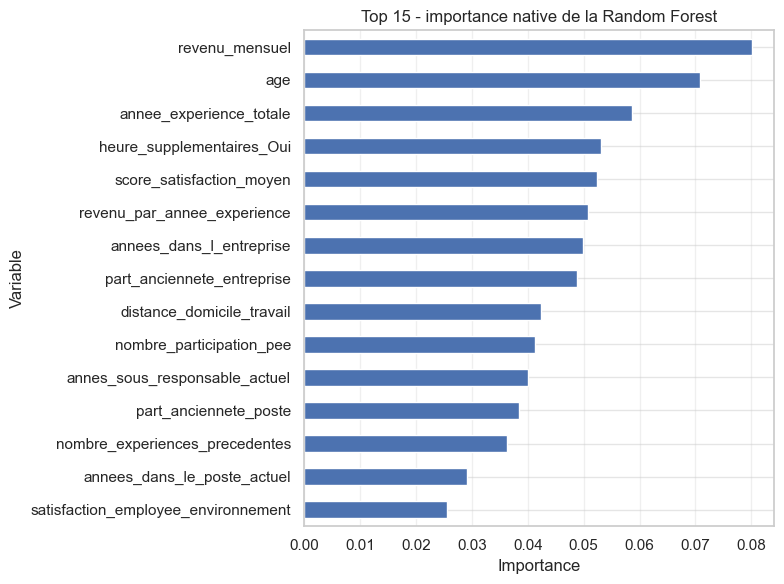

In [21]:
plt.figure (figsize=(8, 6))
native_importance.head (15).sort_values ( ).plot (kind="barh")
plt.title ("Top 15 - importance native de la Random Forest")
plt.xlabel ("Importance")
plt.ylabel ("Variable")
plt.grid (axis="x", alpha=0.3)
plt.tight_layout ( )
plt.show ( )

## 12. Feature importance globale — Permutation Importance

La
permutation
importance
mesure
la
baisse
de
performance
provoquée
par
la
perturbation
d’une
variable.

Elle
est
souvent
plus
fidèle
au
comportement
réel
du
modèle
que
l’importance
native.

In [22]:
perm = permutation_importance (
    best_rf_final,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
    scoring="average_precision",
)

permutation_imp = (
    pd.Series (perm.importances_mean, index=X_test.columns)
    .sort_values (ascending=False)
)

display (permutation_imp.head (20))

heure_supplementaires_Oui                0.091359
nombre_participation_pee                 0.024449
score_satisfaction_moyen                 0.007635
satisfaction_employee_nature_travail     0.007189
frequence_deplacement_Frequent           0.005789
note_evaluation_precedente               0.004342
distance_domicile_travail                0.004046
statut_marital_Marié(e)                  0.003237
nb_formations_suivies                    0.002956
satisfaction_employee_environnement      0.002679
annees_depuis_la_derniere_promotion      0.002223
revenu_mensuel                           0.001822
note_evaluation_actuelle                 0.001625
statut_marital_Divorcé(e)                0.001605
poste_Cadre Commercial                   0.001551
domaine_etude_Entrepreunariat            0.001441
domaine_etude_Transformation Digitale    0.001426
poste_Manager                            0.001403
frequence_deplacement_Occasionnel        0.001051
departement_Consulting                   0.000813


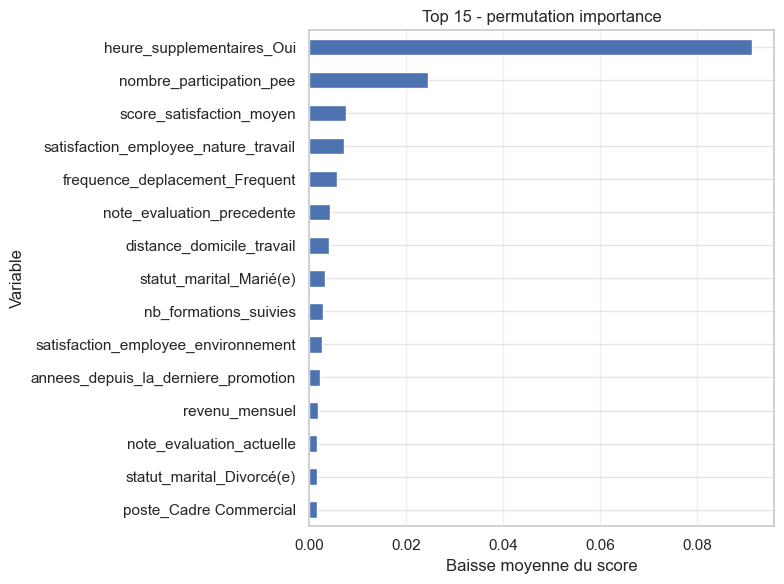

In [23]:
plt.figure (figsize=(8, 6))
permutation_imp.head (15).sort_values ( ).plot (kind="barh")
plt.title ("Top 15 - permutation importance")
plt.xlabel ("Baisse moyenne du score")
plt.ylabel ("Variable")
plt.grid (axis="x", alpha=0.3)
plt.tight_layout ( )
plt.show ( )

## 11. Interprétation des résultats

Le fine-tuning a permis d’obtenir une version optimisée de la Random Forest, mieux adaptée au problème d’attrition.

L’analyse des importances globales montre plusieurs points de convergence entre :
- l’importance native du modèle ;
- la permutation importance ;
- les valeurs SHAP moyennes absolues.

Lorsque certaines variables apparaissent importantes dans les trois méthodes, cela renforce la confiance dans leur rôle global dans les prédictions. À l’inverse, des divergences peuvent apparaître pour des variables corrélées ou pour des variables dont l’effet dépend d’interactions complexes.

Les graphiques SHAP permettent d’aller plus loin que le simple classement des variables. Le beeswarm plot montre non seulement quelles variables influencent le plus le modèle, mais aussi dans quel sens elles poussent la prédiction. Une valeur SHAP positive contribue à augmenter la probabilité de départ, tandis qu’une valeur SHAP négative contribue à la diminuer.

Enfin, les waterfall plots permettent une lecture locale de la prédiction. Ils montrent, pour un individu donné, quelles variables ont le plus contribué à pousser la prédiction vers l’attrition ou vers le maintien dans l’entreprise. Cette lecture locale est particulièrement utile pour expliquer concrètement le comportement du modèle sur des cas individuels.

In [24]:
def get_positive_class_shap_explanation(explainer, X: pd.DataFrame):
    explanation = explainer (X)

    values = explanation.values
    base_values = explanation.base_values

    if values.ndim == 3:
        values = values[:, :, 1]

        if np.ndim (base_values) == 2:
            base_values = base_values[:, 1]
        elif np.ndim (base_values) == 1 and len (base_values) == 2:
            base_values = np.repeat (base_values[1], X.shape[0])

    return shap.Explanation (
        values=values,
        base_values=base_values,
        data=X.values,
        feature_names=X.columns.tolist ( ),
    )

In [25]:
X_shap = X_train.sample (min (300, len (X_train)), random_state=42)

tree_explainer = shap.TreeExplainer (best_rf_final)
shap_explanation = get_positive_class_shap_explanation (tree_explainer, X_shap)

In [26]:
shap_global_importance = (
    pd.Series (np.abs (shap_explanation.values).mean (axis=0), index=X_shap.columns)
    .sort_values (ascending=False)
)

display (shap_global_importance.head (20))

heure_supplementaires_Oui               0.051415
age                                     0.038561
nombre_participation_pee                0.035659
revenu_mensuel                          0.035179
score_satisfaction_moyen                0.030399
annees_dans_l_entreprise                0.026764
annee_experience_totale                 0.025584
annes_sous_responsable_actuel           0.022437
distance_domicile_travail               0.018951
nombre_experiences_precedentes          0.018685
part_anciennete_entreprise              0.015554
satisfaction_employee_environnement     0.015357
part_anciennete_poste                   0.014726
revenu_par_annee_experience             0.013846
departement_Consulting                  0.013297
annees_dans_le_poste_actuel             0.011431
frequence_deplacement_Frequent          0.011405
satisfaction_employee_nature_travail    0.011053
poste_Consultant                        0.009199
annees_depuis_la_derniere_promotion     0.008623
dtype: float64

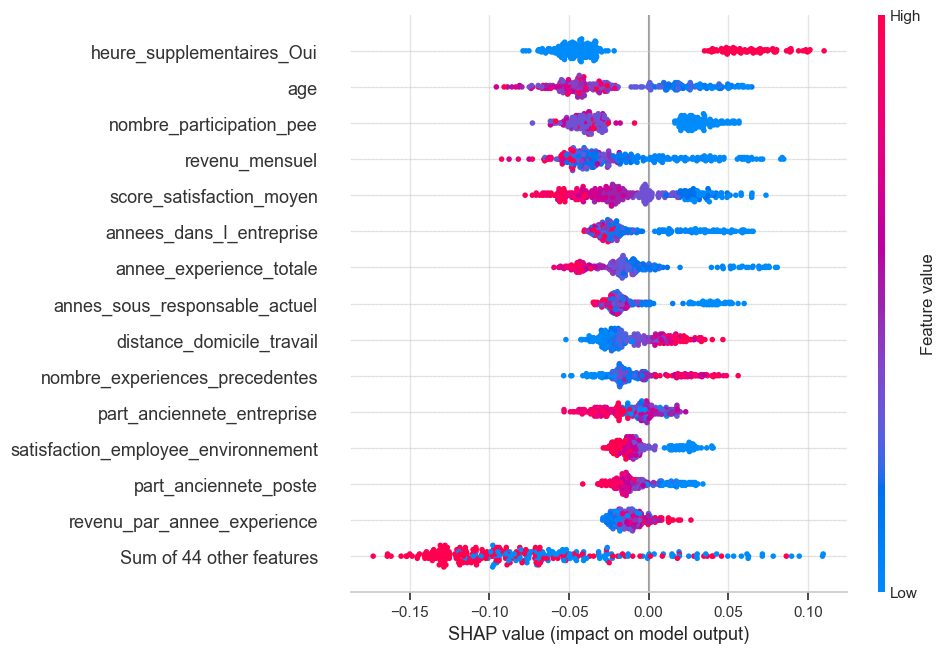

In [27]:
shap.plots.beeswarm (shap_explanation, max_display=15)

## 14. Comparaison des méthodes de feature importance globale

Les trois approches suivantes sont comparées :
- importance native ;
- permutation importance ;
- SHAP (moyenne des valeurs absolues).

In [28]:
importance_compare = pd.concat (
    [
        native_importance.rename ("native_importance"),
        permutation_imp.rename ("permutation_importance"),
        shap_global_importance.rename ("shap_mean_abs"),
    ],
    axis=1,
).fillna (0)

display (
    importance_compare.sort_values ("shap_mean_abs", ascending=False).head (20)
)

,native_importance,permutation_importance,shap_mean_abs
heure_supplementaires_Oui,0.053035,0.091359,0.051415
age,0.070777,-0.003923,0.038561
nombre_participation_pee,0.041236,0.024449,0.035659
revenu_mensuel,0.080053,0.001822,0.035179
score_satisfaction_moyen,0.052347,0.007635,0.030399
annees_dans_l_entreprise,0.049794,-0.025196,0.026764
annee_experience_totale,0.058655,-0.039103,0.025584
annes_sous_responsable_actuel,0.040081,-0.014790,0.022437
distance_domicile_travail,0.042373,0.004046,0.018951
nombre_experiences_precedentes,0.036346,-0.010686,0.018685


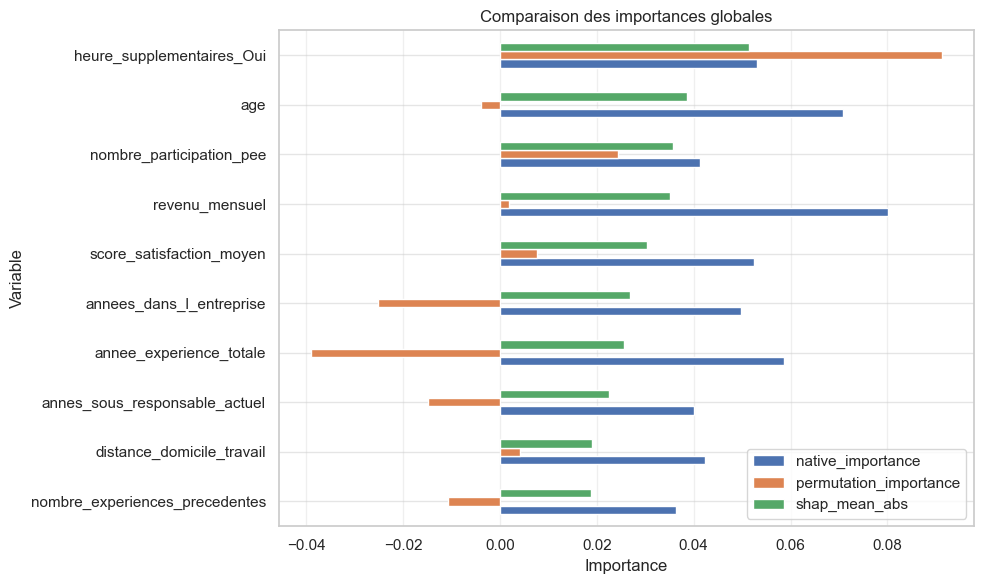

In [29]:
top_features_compare = importance_compare.sort_values (
    "shap_mean_abs", ascending=False
).head (10)

top_features_compare = top_features_compare.sort_values ("shap_mean_abs")

ax = top_features_compare.plot (kind="barh", figsize=(10, 6))
plt.title ("Comparaison des importances globales")
plt.xlabel ("Importance")
plt.ylabel ("Variable")
plt.grid (axis="x", alpha=0.3)
plt.tight_layout ( )
plt.show ( )

## 15. Lecture du sens des Shapley values

Une valeur SHAP positive pousse la prédiction vers la classe positive (`attrition = 1`), tandis qu’une valeur négative la pousse vers la classe négative.

Le graphique suivant aide à interpréter le sens d’une variable et ses interactions avec une autre.

Variable principale : heure_supplementaires_Oui
Variable de coloration : age


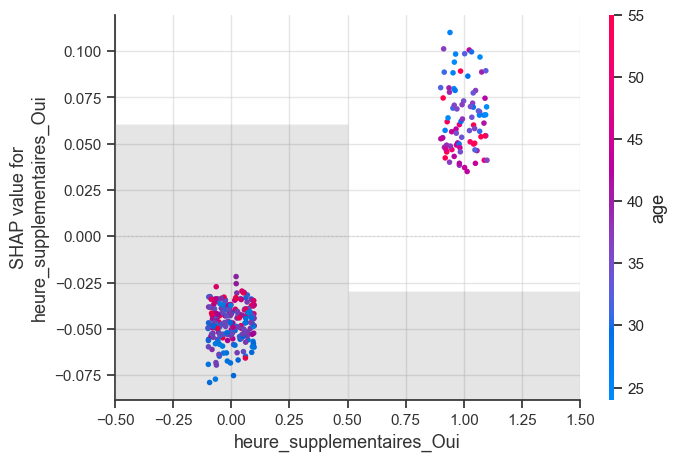

In [30]:
top_shap_features = shap_global_importance.index.tolist ( )

feature_1 = top_shap_features[0]
feature_2 = top_shap_features[1] if len (top_shap_features) > 1 else top_shap_features[0]

print ("Variable principale :", feature_1)
print ("Variable de coloration :", feature_2)

shap.plots.scatter (
    shap_explanation[:, feature_1],
    color=shap_explanation[:, feature_2],
)

## 16. Explications locales avec Waterfall Plot

Les graphiques waterfall permettent d’expliquer une prédiction individuelle.

On sélectionne ici :
- un employé ayant quitté l’entreprise ;
- un employé resté dans l’entreprise.

In [31]:
X_test_reset = X_test.reset_index (drop=True)
y_test_reset = y_test.reset_index (drop=True)

test_results = pd.DataFrame ({
    "y_true": y_test_reset,
    "proba_attrition": best_rf_final.predict_proba (X_test_reset)[:, 1],
})

display (test_results.head ( ))

,y_true,proba_attrition
0,0,0.731222
1,0,0.229964
2,0,0.180839
3,0,0.102993
4,1,0.513222


In [32]:
idx_positive = test_results.loc[test_results["y_true"] == 1, "proba_attrition"].idxmax ( )
idx_negative = test_results.loc[test_results["y_true"] == 0, "proba_attrition"].idxmin ( )

print ("Index exemple classe positive :", idx_positive)
print ("Index exemple classe négative :", idx_negative)

Index exemple classe positive : 200
Index exemple classe négative : 185


In [33]:
shap_test_explanation = get_positive_class_shap_explanation (tree_explainer, X_test_reset)

Exemple classe positive


,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,revenu_par_annee_experience,part_anciennete_entreprise,part_anciennete_poste,score_satisfaction_moyen,genre_M,statut_marital_Divorcé(e),statut_marital_Marié(e),departement_Consulting,departement_Ressources Humaines,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Senior Manager,poste_Tech Lead,heure_supplementaires_Oui,augementation_salaire_precedente_12 %,augementation_salaire_precedente_13 %,augementation_salaire_precedente_14 %,augementation_salaire_precedente_15 %,augementation_salaire_precedente_16 %,augementation_salaire_precedente_17 %,augementation_salaire_precedente_18 %,augementation_salaire_precedente_19 %,augementation_salaire_precedente_20 %,augementation_salaire_precedente_21 %,augementation_salaire_precedente_22 %,augementation_salaire_precedente_23 %,augementation_salaire_precedente_24 %,augementation_salaire_precedente_25 %,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,frequence_deplacement_Frequent,frequence_deplacement_Occasionnel
200,19,2121,1,80,1,1,0,4,2,2,2,4,3,0,3,1,21,3,0,0,1060.5,0.5,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Probabilité de départ : 0.909


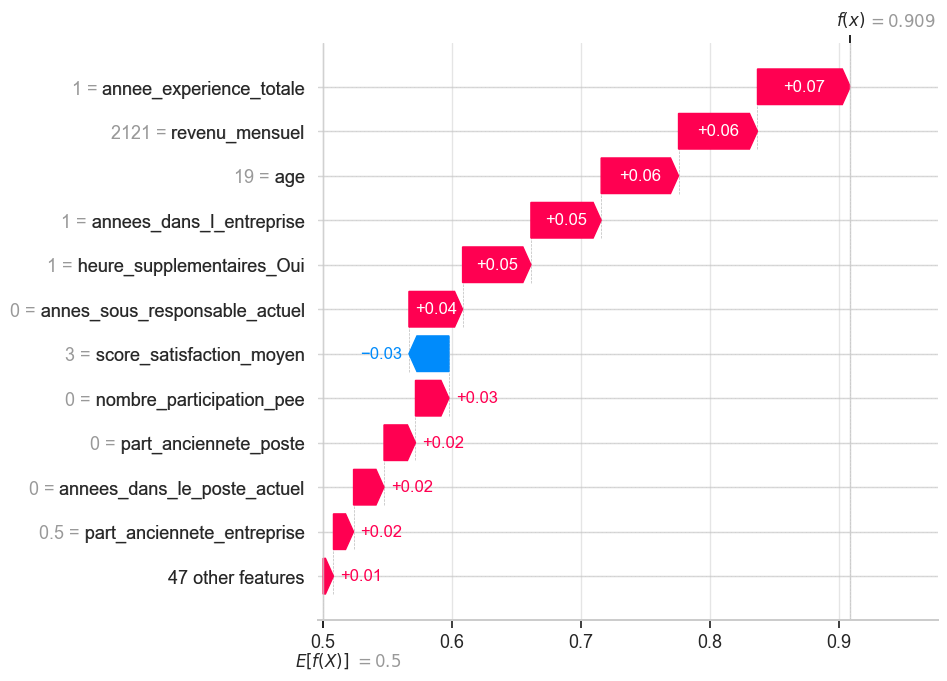

In [34]:
print ("Exemple classe positive")
display (X_test_reset.loc[[idx_positive]])
print ("Probabilité de départ :", round (test_results.loc[idx_positive, "proba_attrition"], 3))

shap.plots.waterfall (shap_test_explanation[idx_positive], max_display=12)

Exemple classe négative


,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,revenu_par_annee_experience,part_anciennete_entreprise,part_anciennete_poste,score_satisfaction_moyen,genre_M,statut_marital_Divorcé(e),statut_marital_Marié(e),departement_Consulting,departement_Ressources Humaines,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Senior Manager,poste_Tech Lead,heure_supplementaires_Oui,augementation_salaire_precedente_12 %,augementation_salaire_precedente_13 %,augementation_salaire_precedente_14 %,augementation_salaire_precedente_15 %,augementation_salaire_precedente_16 %,augementation_salaire_precedente_17 %,augementation_salaire_precedente_18 %,augementation_salaire_precedente_19 %,augementation_salaire_precedente_20 %,augementation_salaire_precedente_21 %,augementation_salaire_precedente_22 %,augementation_salaire_precedente_23 %,augementation_salaire_precedente_24 %,augementation_salaire_precedente_25 %,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,frequence_deplacement_Frequent,frequence_deplacement_Occasionnel
185,32,5470,0,80,10,9,5,4,3,2,3,2,3,2,4,1,2,3,1,6,497.272727,0.818182,0.5,2.75,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


Probabilité de départ : 0.051


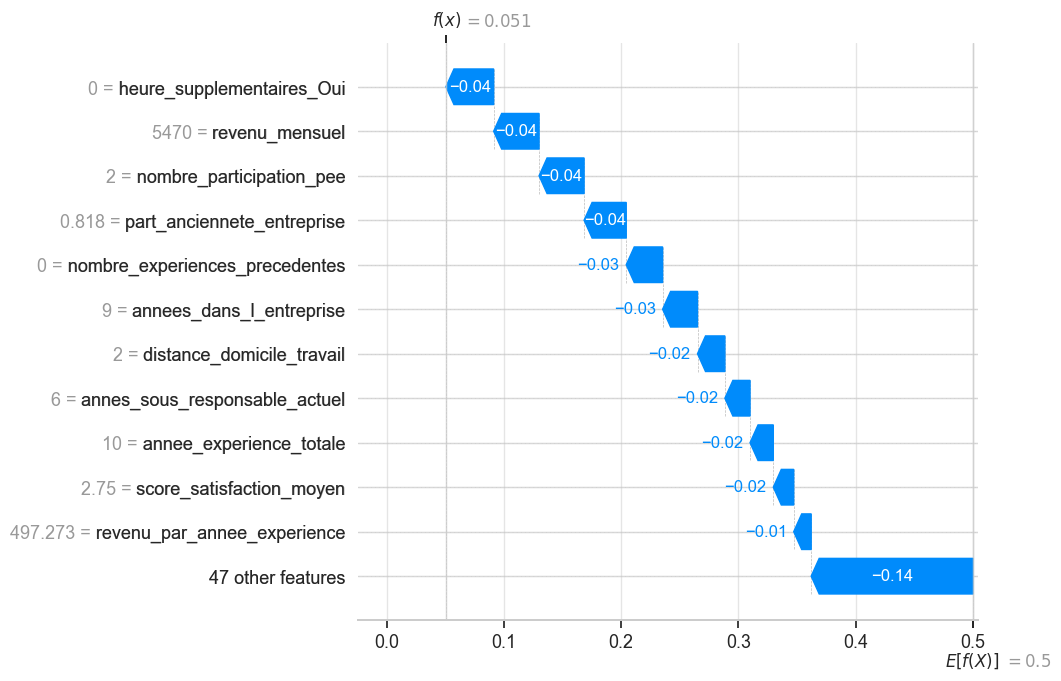

In [35]:
print ("Exemple classe négative")
display (X_test_reset.loc[[idx_negative]])
print ("Probabilité de départ :", round (test_results.loc[idx_negative, "proba_attrition"], 3))

shap.plots.waterfall (shap_test_explanation[idx_negative], max_display=12)

## 17. Analyse d’un faux négatif

L’analyse d’un faux négatif peut être particulièrement utile dans un contexte métier RH, car elle permet de comprendre pourquoi un employé ayant réellement quitté l’entreprise n’a pas été détecté par le modèle.

Index faux négatif : 67
Probabilité de départ : 0.434


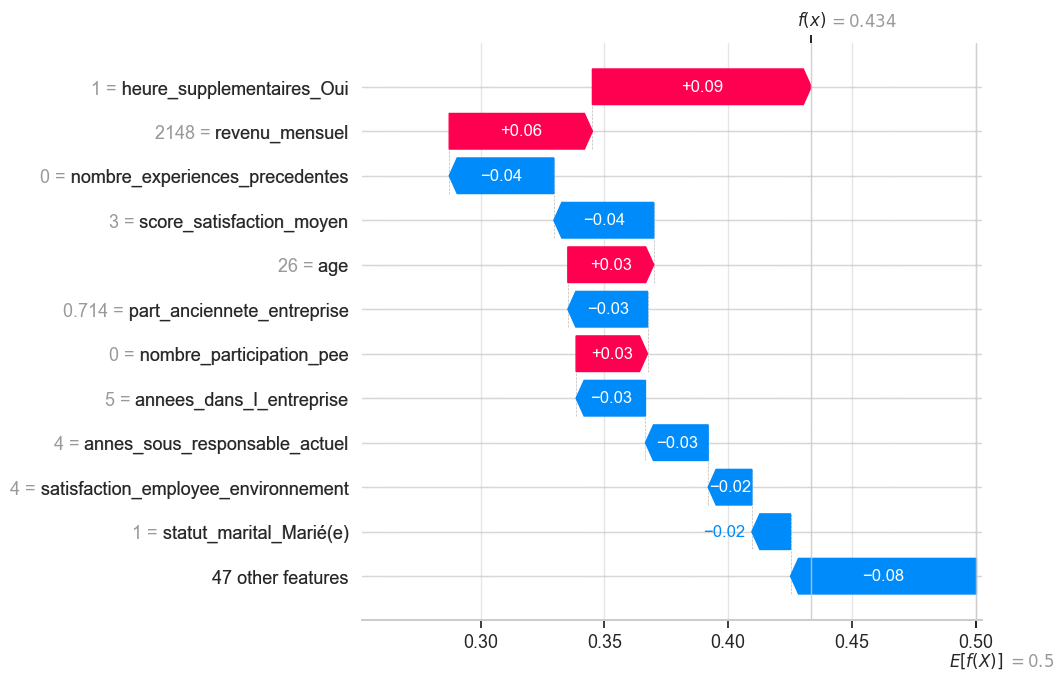

In [36]:
test_results["y_pred_threshold"] = y_test_pred_threshold

false_negatives = test_results[
    (test_results["y_true"] == 1) & (test_results["y_pred_threshold"] == 0)
    ]

if len (false_negatives) > 0:
    idx_fn = false_negatives["proba_attrition"].idxmax ( )
    print ("Index faux négatif :", idx_fn)
    print ("Probabilité de départ :", round (test_results.loc[idx_fn, "proba_attrition"], 3))
    shap.plots.waterfall (shap_test_explanation[idx_fn], max_display=12)
else:
    print ("Aucun faux négatif avec le seuil retenu.")

## 18. Interprétation des résultats

Le fine-tuning a permis d’obtenir une version optimisée de la Random Forest, mieux adaptée au problème d’attrition.

L’analyse des importances globales montre plusieurs points de convergence entre :
- l’importance native du modèle ;
- la permutation importance ;
- les valeurs SHAP moyennes absolues.

Lorsque certaines variables apparaissent importantes dans les trois méthodes, cela renforce la confiance dans leur rôle global dans les prédictions. À l’inverse, des divergences peuvent apparaître pour des variables corrélées ou pour des variables dont l’effet dépend d’interactions complexes.

Les graphiques SHAP permettent d’aller plus loin que le simple classement des variables. Le beeswarm plot montre non seulement quelles variables influencent le plus le modèle, mais aussi dans quel sens elles poussent la prédiction. Une valeur SHAP positive contribue à augmenter la probabilité de départ, tandis qu’une valeur SHAP négative contribue à la diminuer.

Enfin, les waterfall plots permettent une lecture locale de la prédiction. Ils montrent, pour un individu donné, quelles variables ont le plus contribué à pousser la prédiction vers l’attrition ou vers le maintien dans l’entreprise. Cette lecture locale est particulièrement utile pour expliquer concrètement le comportement du modèle sur des cas individuels.

## Conclusion

Cette étape a permis :
- d’optimiser le modèle par recherche d’hyperparamètres ;
- de choisir le seuil de décision sur validation plutôt que sur test ;
- de comparer plusieurs approches d’importance globale ;
- d’expliquer localement certaines prédictions grâce aux waterfall plots.

Le modèle final reste perfectible, mais il est désormais mieux calibré et surtout mieux interprétable, ce qui renforce sa valeur dans un contexte RH.